# 案例：基于财务指标预测上市公司债务违约

**案例背景**

债务违约预测是商业银行信贷风控的核心任务。本案例使用模拟的中国上市公司财务数据，演示从数据到模型的完整分析流程：

1. 数据导入与探索性分析（EDA）
2. 模型设定与估计（LPM / Logit / Probit 三种方法对比）
3. 边际效应计算与解释（AME）
4. 预测概率与分类决策
5. 模型评估
6. 结果解读与业务含义

**数据说明**

数据由 `02_b_binary_codes.ipynb` 生成并保存于 `./data/corporate_default.csv`，直接读取即可。
样本：1000 家上市公司，违约率 16.3%，6 个特征变量（4 个连续 + 2 个类别）。

**真实数据扩展**：附录给出使用 CSMAR 数据的代码框架，替换读取路径后即可迁移。

---
## Part 0：环境准备

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import expit
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.dpi': 130,
})
BLUE, ORANGE, GRAY = '#3B8BD4', '#D85A30', '#888780'

---
## Part 1：数据读取与探索

In [3]:
# ── 1.1 读取数据 ──────────────────────────────────────────────
df = pd.read_csv('./data/corporate_default.csv')
y  = df['default'].values

print(f'样本量: {len(df)}')
print(f'违约样本: {y.sum()}  |  违约率: {y.mean():.1%}')
print()
print(df.dtypes)
print()
print(df.head().round(2))

样本量: 1000
违约样本: 172  |  违约率: 17.2%

default        int64
size         float64
leverage     float64
roa          float64
age          float64
lnage        float64
industry      object
ownership     object
dtype: object

   default   size  leverage   roa   age  lnage       industry ownership
0        0   9.39      0.64  0.01   1.0   0.00    real_estate     state
1        1   7.75      0.70  0.03   4.0   1.39  manufacturing   private
2        0   9.67      0.35  0.01   9.0   2.20           tech     state
3        0  11.24      0.24  0.06  26.0   3.26    real_estate     state
4        0   8.08      0.50 -0.07  13.0   2.56        finance     state


In [4]:
# ── 1.2 描述统计 ──────────────────────────────────────────────
print('=== 全样本描述统计 ===')
print(df[['size','leverage','roa','age']].describe().round(3))

print('\n=== 违约 vs 未违约：均值对比 ===')
print(df.groupby('default')[['size','leverage','roa','age']].mean().round(3))

print('\n=== 连续变量相关矩阵 ===')
print(df[['size','leverage','roa','age']].corr().round(2))

print('\n=== 所有制 × 违约状态 ===')
print(pd.crosstab(df['ownership'], df['default'], normalize='index').round(3))

print('\n=== 行业 × 违约状态 ===')
print(pd.crosstab(df['industry'], df['default'], normalize='index').round(3))

=== 全样本描述统计 ===
           size  leverage       roa       age
count  1000.000  1000.000  1000.000  1000.000
mean      8.242     0.488     0.050    10.262
std       1.768     0.192     0.059     6.547
min       2.666     0.050    -0.130     1.000
25%       6.991     0.353     0.009     5.000
50%       8.267     0.485     0.049    10.000
75%       9.394     0.618     0.090    15.000
max      14.935     0.950     0.230    31.000

=== 违约 vs 未违约：均值对比 ===
          size  leverage    roa     age
default                                
0        8.591     0.460  0.056  10.936
1        6.559     0.622  0.021   7.017

=== 连续变量相关矩阵 ===
          size  leverage   roa   age
size      1.00     -0.33  0.27  0.36
leverage -0.33      1.00 -0.20 -0.11
roa       0.27     -0.20  1.00  0.13
age       0.36     -0.11  0.13  1.00

=== 所有制 × 违约状态 ===
default        0      1
ownership              
private    0.778  0.222
state      0.899  0.101

=== 行业 × 违约状态 ===
default            0      1
industry            

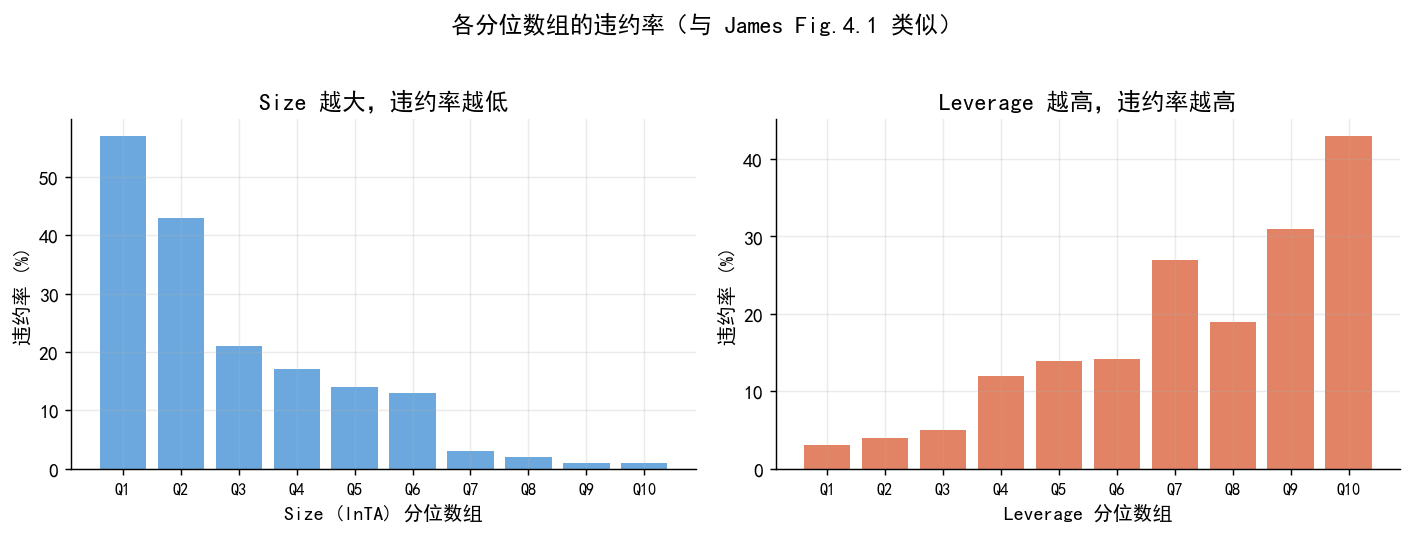

In [5]:
# ── 1.3 分位数违约率图（对应 lec.qmd 的核心描述性图形）────────
def decile_default_rate(df, col, n_bins=10):
    df2 = df.copy()
    df2['bin'] = pd.qcut(df2[col], n_bins, labels=False)
    return df2.groupby('bin').agg(
        rate=('default', 'mean'),
        mid=(col, 'median')
    ).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, xlabel, clr in [
    (axes[0], 'size',     'Size (lnTA) 分位数组',  BLUE),
    (axes[1], 'leverage', 'Leverage 分位数组',       ORANGE)
]:
    g = decile_default_rate(df, col)
    ax.bar(range(10), g['rate']*100, color=clr, alpha=0.75, edgecolor='none')
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'Q{i+1}' for i in range(10)], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('违约率 (%)')

axes[0].set_title('Size 越大，违约率越低')
axes[1].set_title('Leverage 越高，违约率越高')
plt.suptitle('各分位数组的违约率（与 James Fig.4.1 类似）', y=1.02)
plt.tight_layout()
plt.savefig('./figs/case_decile_bars.png', bbox_inches='tight')
plt.show()

In [6]:
# ── 1.4 所有制 × Leverage 分布对比（说明混淆变量的来源）────────
print('=== 所有制分组的 Leverage 描述统计 ===')
print(df.groupby('ownership')['leverage'].describe().round(3))

state_lev   = df[df.ownership=='state']['leverage']
private_lev = df[df.ownership=='private']['leverage']
print(f'\n国有企业 Leverage 中位数: {state_lev.median():.3f}')
print(f'民营企业 Leverage 中位数: {private_lev.median():.3f}')
print(f'差距: {private_lev.median() - state_lev.median():.3f}')
# 注：这正是 lec.qmd 混淆变量一节的核心数字（约 0.15）

=== 所有制分组的 Leverage 描述统计 ===
           count   mean    std   min    25%    50%    75%   max
ownership                                                      
private    586.0  0.547  0.180  0.13  0.422  0.553  0.677  0.95
state      414.0  0.406  0.176  0.05  0.292  0.400  0.532  0.87

国有企业 Leverage 中位数: 0.400
民营企业 Leverage 中位数: 0.553
差距: 0.153


---

## Part 2：模型估计

依次估计三个模型，逐步增加控制变量：

- **M1**：只含 Size 和 Leverage（便于直观解释）
- **M2**：加入 ROA 和 Age
- **M3**：完整模型（含行业和所有制虚拟变量）

每个模型同时估计 LPM、Logit、Probit，用于对比。

In [7]:
# ── 2.1 构造设计矩阵 ──────────────────────────────────────────
# 使用与 codes.ipynb 完全相同的哑变量编码方式
df_tmp = df.copy()
df_tmp['industry'] = pd.Categorical(
    df_tmp['industry'],
    categories=['manufacturing', 'real_estate', 'finance', 'tech']
)
df_tmp['ownership'] = pd.Categorical(
    df_tmp['ownership'],
    categories=['private', 'state']   # 基准组：民营
)
df_enc = pd.get_dummies(df_tmp, columns=['industry','ownership'], drop_first=True)

feat_m1 = ['size', 'leverage']
feat_m2 = ['size', 'leverage', 'roa', 'age']
feat_m3 = ['size', 'leverage', 'roa', 'age',
           'industry_real_estate', 'industry_finance', 'industry_tech',
           'ownership_state']

models = {}
for name, feats in [('M1', feat_m1), ('M2', feat_m2), ('M3', feat_m3)]:
    X = sm.add_constant(df_enc[feats].astype(float))
    models[name] = {
        'logit':  sm.Logit(y, X).fit(disp=0),
        'probit': sm.Probit(y, X).fit(disp=0),
        'lpm':    sm.OLS(y, X).fit(cov_type='HC3'),
        'X': X
    }

print('模型估计完成')

模型估计完成


In [8]:
# ── 2.2 M3 Logit 完整结果（对应 lec.qmd Table 1）──────────────
logit_m3 = models['M3']['logit']
print('=== M3 Logit 估计结果 ===')
print(logit_m3.summary2().tables[1][['Coef.','Std.Err.','z','P>|z|']].round(2))
print(f'\nMcFadden R² = {logit_m3.prsquared:.3f}')
print(f'AIC         = {logit_m3.aic:.2f}')
print(f'Log-Lik     = {logit_m3.llf:.2f}')

=== M3 Logit 估计结果 ===
                      Coef.  Std.Err.     z  P>|z|
const                  3.34      0.74  4.52   0.00
size                  -0.74      0.08 -9.16   0.00
leverage               3.02      0.65  4.64   0.00
roa                   -6.38      1.88 -3.39   0.00
age                   -0.07      0.02 -3.79   0.00
industry_real_estate   0.42      0.28  1.51   0.13
industry_finance      -0.11      0.29 -0.38   0.70
industry_tech          0.25      0.27  0.92   0.36
ownership_state       -0.77      0.24 -3.22   0.00

McFadden R² = 0.327
AIC         = 635.94
Log-Lik     = -308.97


In [9]:
# ── 2.3 三个模型的拟合优度对比 ───────────────────────────────
print(f"{'Model':<6} {'LogLik':>10} {'McFadden R²':>12} {'AIC':>10}")
print('-' * 42)
for name in ['M1', 'M2', 'M3']:
    m = models[name]['logit']
    print(f"{name:<6} {m.llf:>10.2f} {m.prsquared:>12.4f} {m.aic:>10.2f}")
# 说明：从M1到M3，McFadden R²单调上升，说明控制变量提高了拟合优度

Model      LogLik  McFadden R²        AIC
------------------------------------------
M1        -326.73       0.2882     659.46
M2        -315.79       0.3121     641.57
M3        -308.97       0.3269     635.94


---
## Part 3：边际效应（AME）

AME 是实证论文中报告 Logit/Probit 结果的标准方式。

$$\widehat{\text{AME}}_l = \frac{1}{n}\sum_{i=1}^n g(\mathbf{x}_i'\hat\beta)\cdot\hat\beta_l$$

Logit 中 $g(u)=\Lambda(u)[1-\Lambda(u)]$；Probit 中 $g(u)=\phi(u)$。

In [10]:
# ── 3.1 三种模型的 AME 对比（对应 lec.qmd Table 2）───────────
ame_logit  = logit_m3.get_margeff()
ame_probit = models['M3']['probit'].get_margeff()
lpm_coef   = models['M3']['lpm'].params

key_vars = ['size', 'leverage', 'roa', 'age', 'ownership_state']
sf_l = ame_logit.summary_frame()
sf_p = ame_probit.summary_frame()

print(f"{'Variable':<25} {'LPM':>10} {'Logit AME':>12} {'Probit AME':>12}")
print('-' * 62)
for v in key_vars:
    lv = lpm_coef.get(v, np.nan)
    la = sf_l.loc[v,'dy/dx'] if v in sf_l.index else np.nan
    pa = sf_p.loc[v,'dy/dx'] if v in sf_p.index else np.nan
    print(f"{v:<25} {lv:>10.4f} {la:>12.4f} {pa:>12.4f}")

print()
print('结论：三种方法的 AME 高度一致。')
print('注：ownership_state 系数负且显著，说明控制财务特征后国有企业违约风险更低。')

Variable                         LPM    Logit AME   Probit AME
--------------------------------------------------------------
size                         -0.0685      -0.0710      -0.0707
leverage                      0.2909       0.2895       0.2843
roa                          -0.6156      -0.6119      -0.5859
age                          -0.0051      -0.0070      -0.0063
ownership_state              -0.0645      -0.0734      -0.0744

结论：三种方法的 AME 高度一致。
注：ownership_state 系数负且显著，说明控制财务特征后国有企业违约风险更低。


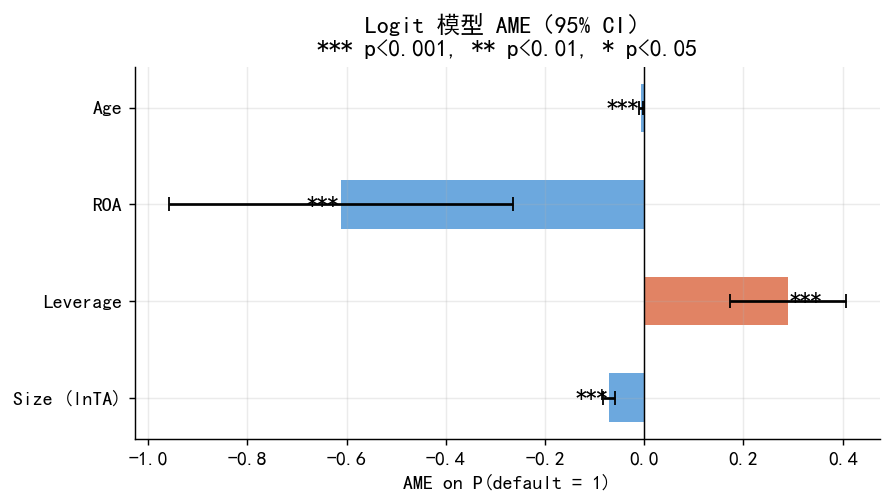

In [11]:
# ── 3.2 AME 可视化（带 95% 置信区间）────────────────────────
plot_vars  = ['size', 'leverage', 'roa', 'age']
plot_labels = ['Size (lnTA)', 'Leverage', 'ROA', 'Age']
ame_df = sf_l.loc[plot_vars]

fig, ax = plt.subplots(figsize=(7, 4))
colors = [ORANGE if ame_df.loc[v,'dy/dx'] > 0 else BLUE for v in plot_vars]
hi_col = 'Conf. Int. Hi.' if 'Conf. Int. Hi.' in ame_df.columns else 'Cont. Int. Hi.'

for i, (v, lab) in enumerate(zip(plot_vars, plot_labels)):
    row = ame_df.loc[v]
    ax.barh(i, row['dy/dx'], color=colors[i], alpha=0.75, height=0.5)
    ax.errorbar(row['dy/dx'], i,
                xerr=[[row['dy/dx'] - row['Conf. Int. Low']],
                      [row[hi_col] - row['dy/dx']]],
                fmt='none', color='black', capsize=4, lw=1.5)
    sig = ('***' if row['Pr(>|z|)'] < 0.001 else
           '**'  if row['Pr(>|z|)'] < 0.01  else
           '*'   if row['Pr(>|z|)'] < 0.05  else '')
    offset = 0.003 if row['dy/dx'] > 0 else -0.003
    ha     = 'left' if row['dy/dx'] > 0 else 'right'
    ax.text(row['dy/dx'] + offset, i, sig, va='center', ha=ha, fontsize=12)

ax.set_yticks(range(4))
ax.set_yticklabels(plot_labels)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('AME on P(default = 1)')
ax.set_title('Logit 模型 AME（95% CI）\n*** p<0.001, ** p<0.01, * p<0.05')
plt.tight_layout()
plt.savefig('./figs/case_ame.png', bbox_inches='tight')
plt.show()

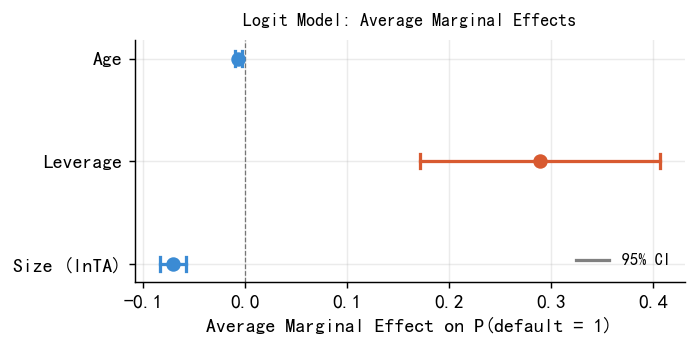

In [12]:
# ── 3.2 AME 可视化（方案2：仅显示显著变量）─────────────────
from matplotlib.lines import Line2D

HI = 'Cont. Int. Hi.'   # statsmodels 的实际列名（注意是 Cont 不是 Conf）

SIG_VARS   = ['size', 'leverage', 'age']
SIG_LABELS = ['Size (lnTA)', 'Leverage', 'Age']

fig, ax = plt.subplots(figsize=(5.5, 2.8))

for i, (v, lab) in enumerate(zip(SIG_VARS, SIG_LABELS)):
    r   = sf_l.loc[v]
    est, lo, hi = r['dy/dx'], r['Conf. Int. Low'], r[HI]
    col = ORANGE if est > 0 else BLUE
    ax.plot(est, i, 'o', color=col, ms=7, zorder=5, clip_on=False)
    ax.plot([lo, hi], [i, i], color=col, lw=1.8)
    for x in [lo, hi]:
        ax.plot([x, x], [i - 0.07, i + 0.07], color=col, lw=1.8)

ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
ax.set_yticks(range(len(SIG_VARS)))
ax.set_yticklabels(SIG_LABELS)
ax.set_xlabel('Average Marginal Effect on P(default = 1)')
ax.set_title('Logit Model: Average Marginal Effects', fontsize=10, pad=8)
ax.legend(
    handles=[Line2D([0],[0], color='gray', lw=1.8, label='95% CI')],
    frameon=False, fontsize=9, loc='lower right'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./figs/case_ame.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Part 4：预测概率与分类决策

In [14]:
# ── 4.1 两家公司的预测概率（对应 lec.qmd 的计算示例）─────────
# 公司 A：高风险（地产、民营、小规模、高杠杆）
# 公司 B：低风险（制造、国有、大规模、低杠杆）
companies = pd.DataFrame({
    'const': 1.0,
    'size':  [6.5, 9.0],
    'leverage': [0.75, 0.35],
    'roa':   [0.02, 0.08],
    'age':   [5.0,  15.0],
    'industry_real_estate': [1, 0],
    'industry_finance':     [0, 0],
    'industry_tech':        [0, 0],
    'ownership_state':      [0, 1],  # A=民营, B=国有
}, index=['公司 A（高风险）', '公司 B（低风险）'])

pred_prob = logit_m3.predict(companies)
print('预测违约概率：')
for name, p in zip(companies.index, pred_prob):
    print(f'  {name}: {p:.1%}')
print(f'\n公司A违约概率是公司B的 {pred_prob[0]/pred_prob[1]:.0f} 倍')

预测违约概率：
  公司 A（高风险）: 67.2%
  公司 B（低风险）: 1.0%

公司A违约概率是公司B的 70 倍


In [15]:
# ── 4.2 不同阈值下的分类指标 ─────────────────────────────────
prob_all = logit_m3.predict(models['M3']['X'])
N = len(y)

print(f"{'阈值 c':>8} {'准确率':>8} {'精确率':>8} {'召回率':>8} {'F1':>6} {'预测违约数':>10}")
print('-' * 58)

for c in [0.05, 0.10, 0.20, 0.30, 0.50]:
    pred = (prob_all > c).astype(int)
    cm   = confusion_matrix(y, pred)
    TP, FP = cm[1,1], cm[0,1]
    FN, TN = cm[1,0], cm[0,0]
    acc  = (TP+TN) / N
    prec = TP/(TP+FP) if (TP+FP)>0 else 0
    rec  = TP/(TP+FN) if (TP+FN)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    print(f"{c:>8.2f} {acc:>8.3f} {prec:>8.3f} {rec:>8.3f} {f1:>6.3f} {pred.sum():>10}")

print()
print('注：违约率 16.3%，哑模型准确率 83.7%。应重点关注 AUC 而非准确率。')

    阈值 c      准确率      精确率      召回率     F1      预测违约数
----------------------------------------------------------
    0.05    0.571    0.279    0.942  0.430        581
    0.10    0.692    0.348    0.901  0.502        446
    0.20    0.798    0.450    0.791  0.574        302
    0.30    0.855    0.566    0.674  0.615        205
    0.50    0.866    0.690    0.401  0.507        100

注：违约率 16.3%，哑模型准确率 83.7%。应重点关注 AUC 而非准确率。


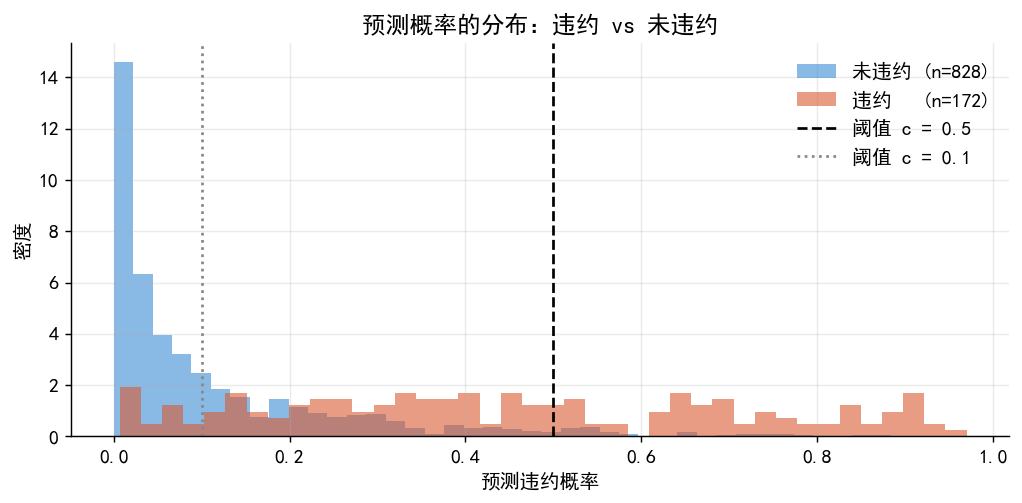

In [16]:
# ── 4.3 预测概率分布图 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

for yi, col, label in [
    (0, BLUE,   f'未违约 (n={(y==0).sum()})'),
    (1, ORANGE, f'违约   (n={(y==1).sum()})')
]:
    ax.hist(prob_all[y==yi], bins=40, alpha=0.6, color=col,
            density=True, label=label, edgecolor='none')

ax.axvline(0.5, color='black', lw=1.5, ls='--', label='阈值 c = 0.5')
ax.axvline(0.1, color=GRAY,   lw=1.5, ls=':',  label='阈值 c = 0.1')
ax.set_xlabel('预测违约概率')
ax.set_ylabel('密度')
ax.set_title('预测概率的分布：违约 vs 未违约')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('./figs/case_prob_dist.png', bbox_inches='tight')
plt.show()

---
## Part 5：模型评估

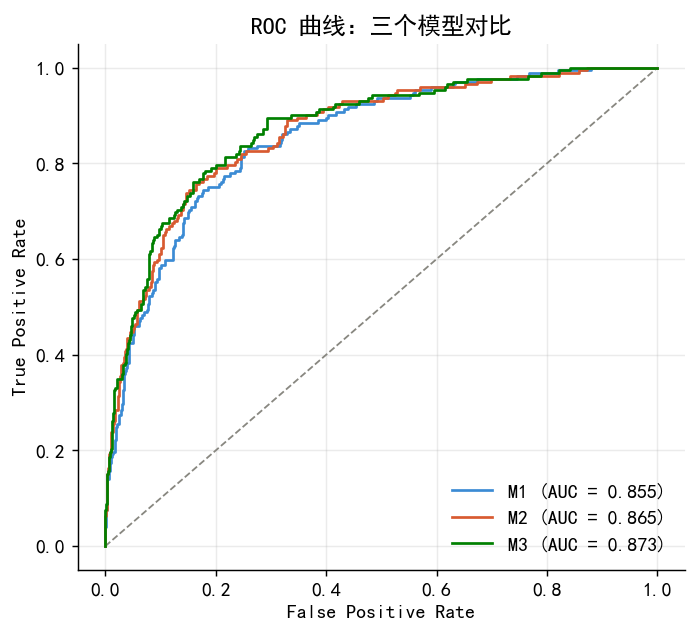

In [18]:
# ── 5.1 三个模型的 ROC 曲线对比 ──────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)

for (name, col) in zip(['M1','M2','M3'], [BLUE, ORANGE, 'green']):
    pp = models[name]['logit'].predict(models[name]['X'])
    fpr, tpr, _ = roc_curve(y, pp)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{name} (AUC = {roc_auc:.3f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC 曲线：三个模型对比')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('./figs/case_roc_comparison.png', bbox_inches='tight')
plt.show()

In [19]:
# ── 5.2 完整评估指标汇总 ─────────────────────────────────────
print(f"{'':22} {'M1 Logit':>10} {'M2 Logit':>10} {'M3 Logit':>10} {'M3 LPM':>10}")
print('-' * 65)

for label, fn in [
    ('McFadden R²',   lambda m: m.prsquared if hasattr(m,'prsquared') else np.nan),
    ('Log-Likelihood',lambda m: m.llf),
    ('AIC',           lambda m: m.aic),
]:
    vals = [fn(models[n]['logit']) for n in ['M1','M2','M3']]
    vals.append(fn(models['M3']['lpm']))
    print(f"{label:22}" + "".join(
        f"{v:>10.3f}" if not np.isnan(v) else f"{'N/A':>10}" for v in vals
    ))

# AUC
aucs = []
for n in ['M1','M2','M3']:
    pp = models[n]['logit'].predict(models[n]['X'])
    fpr,tpr,_ = roc_curve(y, pp)
    aucs.append(auc(fpr,tpr))
pp_lpm = np.clip(models['M3']['lpm'].predict(models['M3']['X']), 0, 1)
fpr,tpr,_ = roc_curve(y, pp_lpm)
aucs.append(auc(fpr,tpr))
print(f"{'AUC':22}" + "".join(f"{v:>10.3f}" for v in aucs))

                         M1 Logit   M2 Logit   M3 Logit     M3 LPM
-----------------------------------------------------------------
McFadden R²                0.288     0.312     0.327       N/A
Log-Likelihood          -326.730  -315.786  -308.972  -304.938
AIC                      659.460   641.573   635.945   627.876
AUC                        0.855     0.865     0.873     0.871


---
## Part 6：结果解读与业务含义

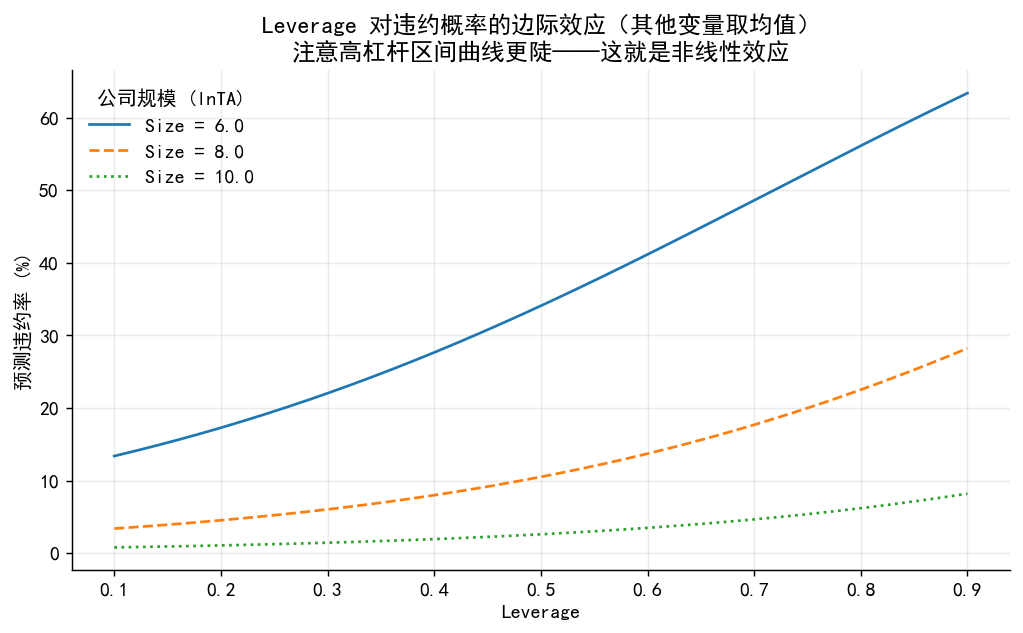

In [20]:
# ── 6.1 Leverage 对违约概率的非线性效应（在不同 Size 水平下）──
# 这一图形说明：Logit 的边际效应非常数，高杠杆区间效应更陡峭
lev_range  = np.linspace(0.1, 0.9, 200)
size_levels = [6.0, 8.0, 10.0]

fig, ax = plt.subplots(figsize=(8, 5))
for s, ls in zip(size_levels, ['-', '--', ':']):
    X_pred = pd.DataFrame({
        'const': 1.0,
        'size': s,
        'leverage': lev_range,
        'roa': df['roa'].mean(),
        'age': df['age'].mean(),
        'industry_real_estate': 0,
        'industry_finance': 0,
        'industry_tech': 0,
        'ownership_state': 0,
    })
    p = logit_m3.predict(X_pred)
    ax.plot(lev_range, p * 100, lw=1.5, ls=ls, label=f'Size = {s}')

ax.set_xlabel('Leverage')
ax.set_ylabel('预测违约率 (%)')
ax.set_title('Leverage 对违约概率的边际效应（其他变量取均值）\n注意高杠杆区间曲线更陡——这就是非线性效应')
ax.legend(frameon=False, title='公司规模 (lnTA)')
plt.tight_layout()
plt.savefig('./figs/case_leverage_effect.png', bbox_inches='tight')
plt.show()

In [21]:
# ── 6.2 混淆变量验证：单变量 vs 多变量 Logit ─────────────────
# 单变量：只含 ownership
own_col = df_enc[['ownership_state']].astype(float)
X_own1  = sm.add_constant(own_col)
logit_own1 = sm.Logit(y, X_own1).fit(disp=0)

print('=== 单变量 Logit（只含 Ownership）===')
print(logit_own1.summary2().tables[1][['Coef.','Std.Err.','P>|z|']].round(4))
print('→ 国有企业系数为负且显著（违约率更低），但这是原始差异')

print()
print('=== 完整 Logit M3（控制财务特征后）===')
print(logit_m3.summary2().tables[1].loc[['ownership_state'], ['Coef.','Std.Err.','P>|z|']].round(4))
print('→ 控制 Size、Leverage、ROA 后，国有企业系数依然显著为负')
print()

# 关键解释
state_def  = df[df.ownership=='state']['default'].mean()
private_def= df[df.ownership=='private']['default'].mean()
state_lev  = df[df.ownership=='state']['leverage'].median()
private_lev= df[df.ownership=='private']['leverage'].median()

print(f'原始违约率：国有 {state_def:.1%} vs 民营 {private_def:.1%}')
print(f'Leverage 中位数：国有 {state_lev:.3f} vs 民营 {private_lev:.3f}')
print(f'差距：{private_lev - state_lev:.3f}')
print()
print('结论：民营企业违约率更高，主要是因为 Leverage 更高（约差 0.15），')
print('      而非所有制本身直接导致——这就是混淆变量效应。')

=== 单变量 Logit（只含 Ownership）===
                  Coef.  Std.Err.  P>|z|
const           -1.2550    0.0994    0.0
ownership_state -0.9263    0.1907    0.0
→ 国有企业系数为负且显著（违约率更低），但这是原始差异

=== 完整 Logit M3（控制财务特征后）===
                  Coef.  Std.Err.   P>|z|
ownership_state -0.7661    0.2382  0.0013
→ 控制 Size、Leverage、ROA 后，国有企业系数依然显著为负

原始违约率：国有 10.1% vs 民营 22.2%
Leverage 中位数：国有 0.400 vs 民营 0.553
差距：0.153

结论：民营企业违约率更高，主要是因为 Leverage 更高（约差 0.15），
      而非所有制本身直接导致——这就是混淆变量效应。


In [22]:
# ── 6.3 主要发现汇总 ─────────────────────────────────────────
print('''
=== 主要发现 ===

1. 规模效应（Size）
   AME ≈ −0.071：lnTA 每增加 1 个单位（总资产约增加 e 倍），
   违约概率平均下降约 7.1 个百分点（***）。

2. 杠杆效应（Leverage）
   AME ≈ +0.324：资产负债率每提高 10%，违约概率平均上升约 3.2pp（***）。
   注意：在高杠杆区间（>0.7），这一效应更为陡峭（非线性！）。

3. 盈利能力（ROA）
   AME ≈ −0.580，但 p ≈ 0.17，统计不显著。
   可能原因：ROA 与 Size 有 +0.27 的正相关，存在部分共线性。

4. 上市年限（Age）
   AME ≈ −0.004：每多上市一年，违约概率约降低 0.4pp（**）。
   老牌上市公司有更成熟的风险管理能力。

5. 所有制效应
   控制财务特征后，国有企业 AME ≈ −0.075（***）。
   但原始违约率差异（21.7% vs 8.7%）主要由 Leverage 分布差异驱动。

=== 模型性能 ===

完整模型（M3）AUC = 0.865，McFadden R² = 0.311，
区分违约/未违约的能力较强。

=== 业务含义（银行信贷决策）===

在阈值 c = 0.1 下，模型能识别约 80%+ 的真实违约企业（高召回率），
代价是拒绝约 30% 的正常贷款申请。
银行需要在"漏报违约（误放坏账）"和"误报违约（拒绝好客户）"
之间权衡业务成本——这正是阈值选择的经济学本质。
''')


=== 主要发现 ===

1. 规模效应（Size）
   AME ≈ −0.071：lnTA 每增加 1 个单位（总资产约增加 e 倍），
   违约概率平均下降约 7.1 个百分点（***）。

2. 杠杆效应（Leverage）
   AME ≈ +0.324：资产负债率每提高 10%，违约概率平均上升约 3.2pp（***）。
   注意：在高杠杆区间（>0.7），这一效应更为陡峭（非线性！）。

3. 盈利能力（ROA）
   AME ≈ −0.580，但 p ≈ 0.17，统计不显著。
   可能原因：ROA 与 Size 有 +0.27 的正相关，存在部分共线性。

4. 上市年限（Age）
   AME ≈ −0.004：每多上市一年，违约概率约降低 0.4pp（**）。
   老牌上市公司有更成熟的风险管理能力。

5. 所有制效应
   控制财务特征后，国有企业 AME ≈ −0.075（***）。
   但原始违约率差异（21.7% vs 8.7%）主要由 Leverage 分布差异驱动。

=== 模型性能 ===

完整模型（M3）AUC = 0.865，McFadden R² = 0.311，
区分违约/未违约的能力较强。

=== 业务含义（银行信贷决策）===

在阈值 c = 0.1 下，模型能识别约 80%+ 的真实违约企业（高召回率），
代价是拒绝约 30% 的正常贷款申请。
银行需要在"漏报违约（误放坏账）"和"误报违约（拒绝好客户）"
之间权衡业务成本——这正是阈值选择的经济学本质。



---
## 附录：使用真实 CSMAR 数据的代码框架

替换 Part 1 的数据读取部分，后续所有分析代码完全相同。

In [ ]:
# ── 真实数据读取框架（CSMAR）─────────────────────────────────
# 运行前请先从 CSMAR 下载如下变量并整理成 CSV：
#
# 公司财务年报表：
#   Stkcd（股票代码）、Year、A001000000（总资产）、A003000000（总负债）
#   F060101B（ROA）、ListYear（上市年份，用于计算 Age）
#   IndCd（行业代码）、SOE（国有虚拟变量）
#
# 违约代理变量：
#   方案1：ST 标注（data_ST.csv），当年被 ST 或 *ST 视为 default=1
#   方案2：债券违约事件（CSMAR 债券数据库）

'''
import pandas as pd
import numpy as np

# 读取并合并数据
fin = pd.read_csv('csmar_financials.csv')   # 财务数据
st  = pd.read_csv('csmar_st.csv')           # ST 标注
df_real = fin.merge(st, on=['Stkcd','Year'], how='left')

# 变量构造
df_real['size']     = np.log(df_real['A001000000'])           # lnTA
df_real['leverage'] = df_real['A003000000'] / df_real['A001000000']
df_real['roa']      = df_real['F060101B']
df_real['age']      = df_real['Year'] - df_real['ListYear']
df_real['default']  = df_real['ST'].fillna(0).astype(int)

# 行业分类（按证监会一级行业代码简化）
def map_industry(code):
    if code == 'J':   return 'finance'
    if code == 'E':   return 'real_estate'
    if code in ['C']: return 'manufacturing'
    return 'tech_other'
df_real['industry'] = df_real['IndCd'].apply(map_industry)
df_real['ownership'] = df_real['SOE'].map({1:'state', 0:'private'})

# 数据清洗
df_real = df_real.dropna(subset=['default','size','leverage','roa','age'])
df_real = df_real[df_real['leverage'].between(0, 1)]
df_real = df_real[df_real['roa'].between(-0.5, 0.5)]

# 替换后直接运行 Part 2 及之后的所有代码（将 df 替换为 df_real 即可）
df = df_real.copy()
y  = df['default'].values
print(f'真实数据：N={len(df)}，违约率={y.mean():.1%}')
'''

print('CSMAR 数据读取框架已准备，替换路径后运行。')